No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Dataset Preview:
                              text  sentiment
0              I love this product          1
1           This movie was amazing          1
2        The service was excellent          1
3  I really enjoyed the experience          1
4     The product quality is great          1
5                 I hate this item          0
6       This is the worst purchase          0
7      The experience was terrible          0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


Predictions:

Text: I love this product
Label: POSITIVE
Score: 0.9998788833618164

Text: This movie was amazing
Label: POSITIVE
Score: 0.9998817443847656

Text: The service was excellent
Label: POSITIVE
Score: 0.9998462200164795

Text: I really enjoyed the experience
Label: POSITIVE
Score: 0.9998757839202881

Text: The product quality is great
Label: POSITIVE
Score: 0.9998745918273926

Text: I hate this item
Label: NEGATIVE
Score: 0.9996969699859619

Text: This is the worst purchase
Label: NEGATIVE
Score: 0.9997817873954773

Text: The experience was terrible
Label: NEGATIVE
Score: 0.9995081424713135


Final Result Table:
                              text  sentiment Predicted_Label  \
0              I love this product          1        POSITIVE   
1           This movie was amazing          1        POSITIVE   
2        The service was excellent          1        POSITIVE   
3  I really enjoyed the experience          1        POSITIVE   
4     The product quality is great          1

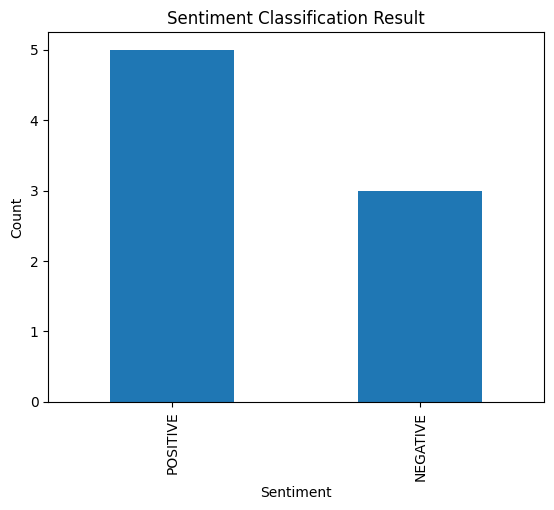

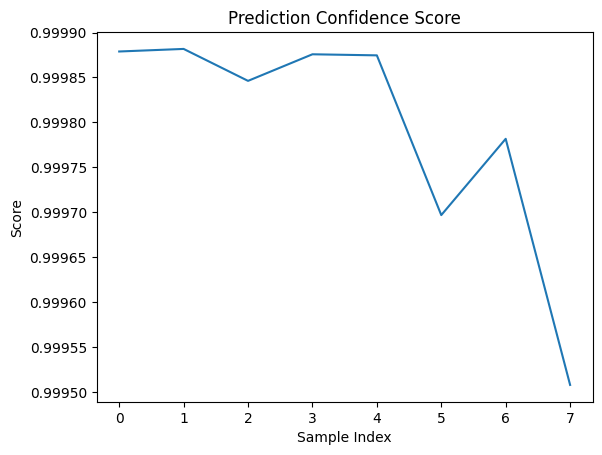

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline


data = {
    "text": [
        "I love this product",
        "This movie was amazing",
        "The service was excellent",
        "I really enjoyed the experience",
        "The product quality is great",
        "I hate this item",
        "This is the worst purchase",
        "The experience was terrible"
    ],
    "sentiment":[1,1,1,1,1,0,0,0]
}

df = pd.DataFrame(data)

print("Dataset Preview:")
print(df)


classifier = pipeline("sentiment-analysis")

labels=[]
scores=[]

print("\nPredictions:\n")

for text in df["text"]:

    result = classifier(text)[0]

    print("Text:", text)
    print("Label:", result["label"])
    print("Score:", result["score"])
    print()

    labels.append(result["label"])
    scores.append(result["score"])


df["Predicted_Label"]=labels
df["Confidence_Score"]=scores

print("\nFinal Result Table:")
print(df)


plt.figure()
df["Predicted_Label"].value_counts().plot(kind="bar")
plt.title("Sentiment Classification Result")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


plt.figure()
plt.plot(df["Confidence_Score"])
plt.title("Prediction Confidence Score")
plt.xlabel("Sample Index")
plt.ylabel("Score")
plt.show()